In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

In [ ]:
df = pd.read_csv("/content/netflix_data.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Display basic info
df.info()

# Check missing values
print(df.isnull().sum())

# Check duplicates
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   duration      7787 non-null   int64 
 9   description   7787 non-null   object
 10  genre         7787 non-null   object
dtypes: int64(2), object(9)
memory usage: 669.3+ KB
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
duration           0
description        0
genre              0
dtype: int64
0


# Data Preprocessing

Handling missing values

In [ ]:
# Check missing values BEFORE
print("Missing Values BEFORE:\n")
print(df.isnull().sum())

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Handle numerical columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Handle categorical columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])



# Check missing values AFTER
print("\nMissing Values AFTER:\n")
print(df.isnull().sum())

# Show sample data
print("\nUpdated Data (First 5 Rows):\n")
print(df.head())

Missing Values BEFORE:

show_id            0
type               0
title              0
director        2388
cast             718
country          507
date_added        98
release_year       0
duration           0
description        0
genre              0
year_added         0
dtype: int64

Missing Values AFTER:

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
duration         0
description      0
genre            0
year_added       0
dtype: int64

Updated Data (First 5 Rows):

  show_id     type  title                director  \
0      s1  TV Show     3%  Raúl Campos, Jan Suter   
1      s2    Movie   7:19       Jorge Michel Grau   
2      s3    Movie  23:59            Gilbert Chan   
3      s4    Movie      9             Shane Acker   
4      s5    Movie     21          Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Co

# Data Cleaning

In [ ]:
# BEFORE cleaning
print("Duplicates BEFORE:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# AFTER cleaning
print("Duplicates AFTER:", df.duplicated().sum())

# Fix column names
df.columns = df.columns.str.strip()

print("\nUpdated Column Names:")
print(df.columns)

# Show updated dataset
print("\nFirst 5 rows after cleaning:")
print(df.head())

Duplicates BEFORE: 0
Duplicates AFTER: 0

Updated Column Names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'duration', 'description', 'genre'],
      dtype='object')

First 5 rows after cleaning:
  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

          date_added  releas

# Feature Transformation

In [ ]:
# Check columns first
print("Columns in dataset:\n", df.columns)

if 'date_added' in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year_added'] = df['date_added'].dt.year

    print("\nFeature Transformation Applied: 'year_added' created")

else:
    print("\nColumn 'date_added' not found → skipping transformation")

# Show result
print("\nFirst 5 rows after transformation:")
print(df.head())

Columns in dataset:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'duration', 'description', 'genre'],
      dtype='object')

Feature Transformation Applied: 'year_added' created

First 5 rows after transformation:
  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

  date_adde

# Encoding

1) Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_label = df.copy()

# Select categorical columns
cat_cols = df_label.select_dtypes(include=['object']).columns

print("Categorical Columns:\n", cat_cols)

# Apply Label Encoding
le = LabelEncoder()

for col in cat_cols:
    df_label[col] = le.fit_transform(df_label[col])

print("\nAfter Label Encoding:\n")
print(df_label.head())

Categorical Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'description', 'genre'],
      dtype='object')

After Label Encoding:

   show_id  type  title  director  cast  country date_added  release_year  \
0        0     1     82      4049  3160        6 2020-08-14          2020   
1     1111     0    124      1840  1589       42 2016-12-23          2016   
2     2222     0     67      1289  6200       60 2018-12-20          2011   
3     3333     0    126      3445  1788       75 2017-11-16          2009   
4     4444     0     60      3176  2924       75 2020-01-01          2008   

   duration  description  genre  year_added  
0         4         3912     16      2020.0  
1        93         1390     12      2016.0  
2        78         7172     13      2018.0  
3        80         3936      0      2017.0  
4       123          138     12      2020.0  


2) One-Hot Encoding

In [ ]:
# Copy dataset
df_ohe = df.copy()

# Select categorical columns
cat_cols = df_ohe.select_dtypes(include=['object']).columns

print("Categorical Columns:\n", cat_cols)

# Apply One-Hot Encoding
df_ohe = pd.get_dummies(df_ohe, columns=cat_cols).astype(int)

print("\nAfter One-Hot Encoding:\n")
print(df_ohe.head())

print("\nNew Columns Created:\n")
print(df_ohe.columns)

Categorical Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country',
       'description', 'genre'],
      dtype='object')

After One-Hot Encoding:

            date_added  release_year  duration  year_added  show_id_s1  \
0  1597363200000000000          2020         4        2020           1   
1  1482451200000000000          2016        93        2016           0   
2  1545264000000000000          2011        78        2018           0   
3  1510790400000000000          2009        80        2017           0   
4  1577836800000000000          2008       123        2020           0   

   show_id_s10  show_id_s100  show_id_s1000  show_id_s1001  show_id_s1002  \
0            0             0              0              0              0   
1            0             0              0              0              0   
2            0             0              0              0              0   
3            0             0              0              0              0   
4 

# Scaling / Normalization

1) Standardization(Z-score Scaling)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Copy dataset
df_std = df.copy()

# Select numerical columns
num_cols = df_std.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:\n", num_cols)

# Apply Standardization
scaler = StandardScaler()
df_std[num_cols] = scaler.fit_transform(df_std[num_cols])

# Show output

print("\nAfter Standardization:\n")
print(df_std.head())

Numerical Columns:
 Index(['release_year', 'duration', 'year_added'], dtype='object')

After Standardization:

  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

  date_added  release_year  duration  \
0 2020-08-14      0.692878 -1.278234   
1 2016-12-23      0.236092  0.468664   
2 2018-12-20     -0.334890  0.174243   
3 2017-11-16 

2) Normalization(Min-Max Scaling)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Copy dataset
df_norm = df.copy()

# Select numerical columns
num_cols = df_norm.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:\n", num_cols)

# Apply Normalization
scaler =



df_norm[num_cols] = scaler.fit_transform(df_norm[num_cols])

# Show output
print("\nAfter Normalization:\n")
print(df_norm.head())

Numerical Columns:
 Index(['release_year', 'duration', 'year_added'], dtype='object')

After Normalization:

  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

  date_added  release_year  duration  \
0 2020-08-14      0.989583  0.009646   
1 2016-12-23      0.947917  0.295820   
2 2018-12-20      0.895833  0.247588   
3 2017-11-16   

# Visualizations with EDA

# UNIVARIATE
1) Histogram(Shows data distribution)


Selected Column for Histogram: release_year


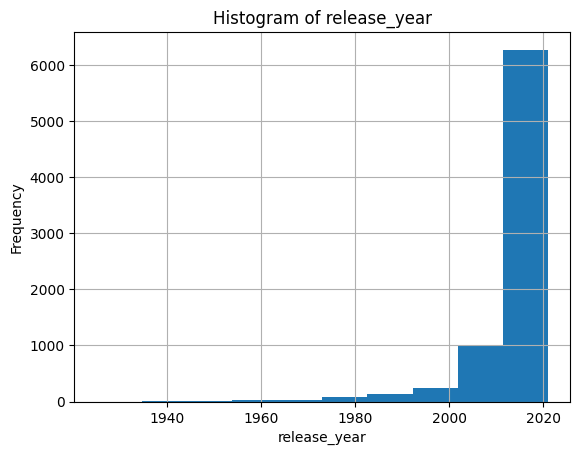

In [ ]:
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

col = num_cols[0]

print("Selected Column for Histogram:", col)

# Plot
plt.figure()
df[col].hist()
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

2) Boxplot(Detects outliers)

Selected Column for Boxplot: release_year


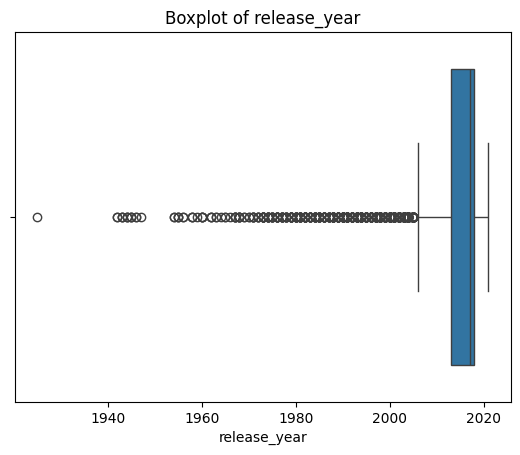

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

col = num_cols[0]

print("Selected Column for Boxplot:", col)

# Plot
plt.figure()
sns.boxplot(x=df[col])
plt.title(f"Boxplot of {col}")
plt.show()

# BIVARIATE
3) Scatter Plot(Shows correlation)




Scatter Plot between release_year and duration


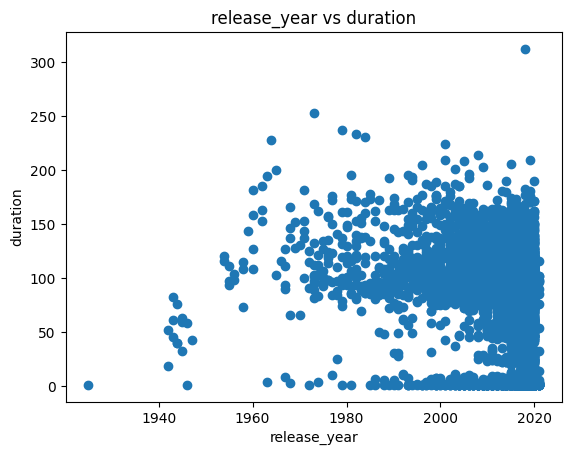

In [ ]:
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

if len(num_cols) >= 2:
    col1 = num_cols[0]
    col2 = num_cols[1]

    print(f"Scatter Plot between {col1} and {col2}")

    plt.figure()
    plt.scatter(df[col1], df[col2])
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs {col2}")
    plt.show()
else:
    print("Not enough numerical columns")

4) Heatmap(Shows relationships between all variables)

Correlation Matrix:

              release_year  duration  year_added
release_year      1.000000 -0.240836    0.099058
duration         -0.240836  1.000000    0.026467
year_added        0.099058  0.026467    1.000000


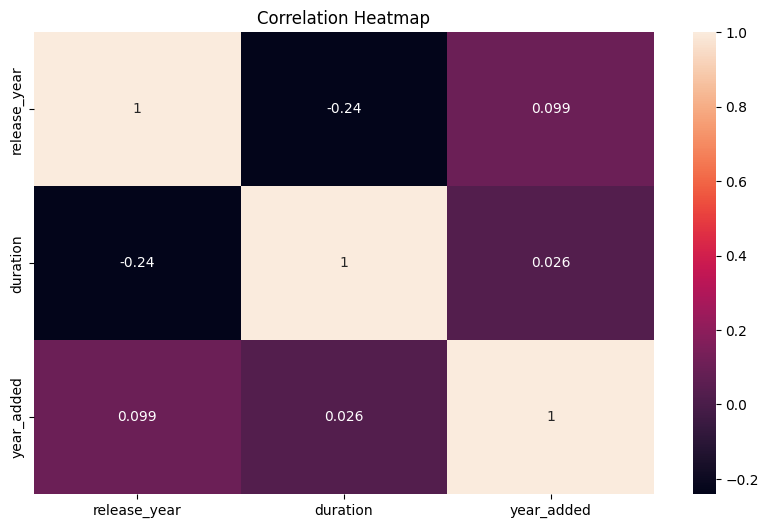

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Correlation Matrix:\n")
print(numeric_df.corr())

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()
